# Tech Challenge Fase 4 - LSTM Stock Price Prediction

Este notebook implementa um modelo LSTM completo para previsão de preços de ações, incluindo:
1. Coleta de dados com yfinance
2. Pré-processamento e normalização
3. Construção e treinamento do modelo LSTM
4. Avaliação e métricas de performance
5. Salvamento do modelo para deploy em API

**Empresa escolhida:** Apple (AAPL)  
**Período de dados:** Últimos 5 anos  
**Métricas de avaliação:** MAE, RMSE, MAPE

## 1. Instalçao e importação das bibliotecas.

In [ ]:
# requirements.txt utilizando as versões mais recentes dos pacotes
pip install -r ../requirements.txt

  Using cached numpy-2.4.5-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 87.9 MB/s  0:00:006m0:00:01
  Attempting uninstall: uvicorn
    Found existing installation: uvicorn 0.46.0
    Uninstalling uvicorn-0.46.0:
      Successfully uninstalled uvicorn-0.46.0
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [numpy]32m1/2 [numpy]
Note: you may need to restart the kernel to use updated packages.


In [8]:
import sys
sys.path.append('/home/raulg/dev/laughing-couscous')

# Data e finanças
import yfinance as yf
import pandas as pd
import numpy as np

# Metricas
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Graficos
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings

# Outras coisas que a IA me disse para importar
from src.data.data_collector import StockDataCollector, DataPreprocessor
from src.models.lstm_model import LSTMModel

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Parece que funciona!")
print(f"TensorFlow : {tf.__version__}")
print(f"Pandas : {pd.__version__}")
print(f"NumPy : {np.__version__}")

✓ Parece que funciona!
TensorFlow : 2.21.0
Pandas : 3.0.3
NumPy : 2.4.5


## 2. Data Collection

Coletaremos dados históricos de preços de ações da Apple (AAPL) dos últimos 5 anos.

In [ ]:
# Configuration
STOCK_SYMBOL = 'AAPL'  # Apple Inc.
START_DATE = '2019-01-01'
END_DATE = datetime.now().strftime('%Y-%m-%d')

print(f"Obtendo dados da {STOCK_SYMBOL} de {START_DATE} até {END_DATE}...")

# Create data collector
collector = StockDataCollector(STOCK_SYMBOL, START_DATE, END_DATE)

# Download data
df = collector.download()

# Display basic information
print(f"\n📊 Stock Data Summary:")
print(f"Symbol: {STOCK_SYMBOL}")
print(f"Total records: {len(df)}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData statistics:")
print(df.describe())

# Check for missing values
missing = df.isnull().sum()
if missing.any():
    print(f"\n⚠️ Missing values:\n{missing[missing > 0]}")
else:
    print("\n✓ No missing values found!")
    
# Get company info
info = collector.get_info()
print(f"\nCompany Information:")
for key, value in info.items():
    print(f"  {key}: {value}")

INFO:src.data.data_collector:Initialized StockDataCollector for AAPL from 2019-01-01 to 2026-05-13
INFO:src.data.data_collector:Downloading data for AAPL...
INFO:src.data.data_collector:Downloaded 1850 records



📊 Stock Data Summary:
Symbol: AAPL
Total records: 1850
Date range: 2019-01-02 to 2026-05-12

First 5 rows:
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2019-01-02  37.469208  37.689868  36.593692  36.750289  148158800
2019-01-03  33.736992  34.574544  33.691911  34.161698  365248800
2019-01-04  35.177197  35.246006  34.118988  34.292192  234428400
2019-01-07  35.098896  35.312438  34.617244  35.281593  219111200
2019-01-08  35.768002  36.021879  35.238897  35.485653  164101200

Data statistics:
Price         Close         High          Low         Open        Volume
Ticker         AAPL         AAPL         AAPL         AAPL          AAPL
count   1850.000000  1850.000000  1850.000000  1850.000000  1.850000e+03
mean     153.804272   155.360111   152.094780   153.655199  8.648319e+07
std       64.617891    65.174086    64.019065    64.57

## 3. Data Preprocessing and Exploration

Vamos explorar o comportamento do preço de fechamento da ação ao longo do tempo.

In [13]:
# Display statistics for each column
print("\n📈 Closing Price Statistics:")
print(f"Mean: ${np.mean(df['Close'].values):.2f}")
print(f"Median: ${np.median(df['Close'].values):.2f}")
print(f"Min: ${np.min(df['Close'].values):.2f}")
print(f"Max: ${np.max(df['Close'].values):.2f}")
print(f"Std Dev: ${np.std(df['Close'].values):.2f}")


📈 Closing Price Statistics:
Mean: $153.80
Median: $154.29
Min: $33.74
Max: $294.80
Std Dev: $64.60


## 4. Data Normalization and Sequence Creation

Normalizaremos os dados e criaremos sequências para treinar o modelo LSTM.

INFO:src.data.data_collector:Starting data preprocessing...
INFO:src.data.data_collector:Training samples: 1235
INFO:src.data.data_collector:Validation samples: 125
INFO:src.data.data_collector:Test samples: 310


Preprocessing configuration:
  Lookback period: 60 days
  Test set size: 20.0%
  Validation set size: 10.0%

✓ Data prepared successfully!
X_train shape: (1235, 60)
y_train shape: (1235,)
X_val shape: (125, 60)
y_val shape: (125,)
X_test shape: (310, 60)
y_test shape: (310,)


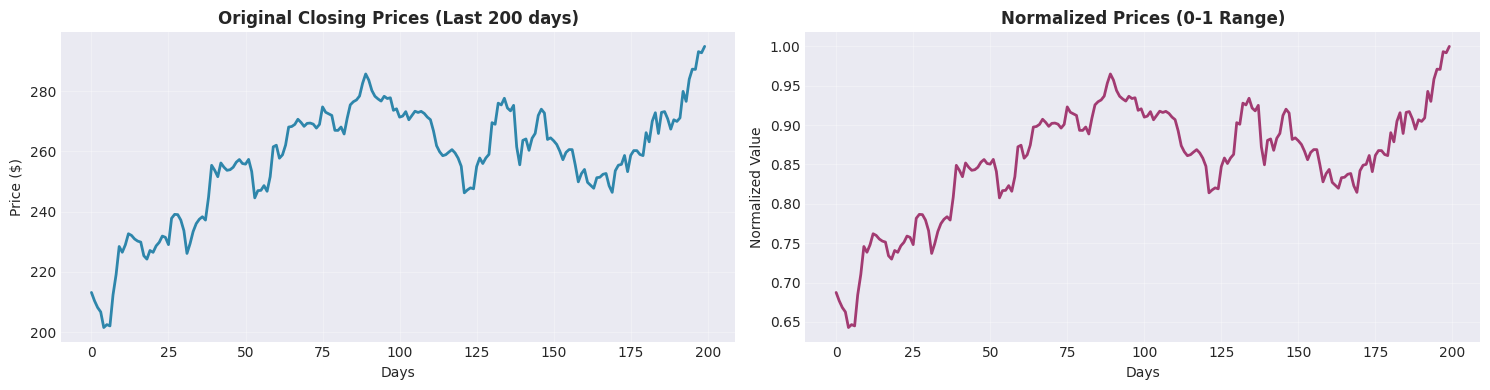

✓ Normalization visualization saved!


In [14]:
# Configuration for preprocessing
LOOKBACK_PERIOD = 60  # Number of days to look back
TEST_SIZE = 0.2
VAL_SIZE = 0.1

print(f"Preprocessing configuration:")
print(f"  Lookback period: {LOOKBACK_PERIOD} days")
print(f"  Test set size: {TEST_SIZE * 100}%")
print(f"  Validation set size: {VAL_SIZE * 100}%")

# Create preprocessor
preprocessor = DataPreprocessor(df, lookback=LOOKBACK_PERIOD)

# Prepare data
data_dict, info_dict = preprocessor.prepare_data(test_size=TEST_SIZE, val_size=VAL_SIZE)

# Extract training data
X_train = data_dict['X_train']
y_train = data_dict['y_train']
X_val = data_dict['X_val']
y_val = data_dict['y_val']
X_test = data_dict['X_test']
y_test = data_dict['y_test']

scaler = info_dict['scaler']

print(f"\n✓ Data prepared successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Visualize normalized data
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Original vs Normalized
original_prices = df['Close'].values[-200:]
axes[0].plot(original_prices, linewidth=2, color='#2E86AB')
axes[0].set_title('Original Closing Prices (Last 200 days)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Price ($)')
axes[0].grid(True, alpha=0.3)

normalized_prices = scaler.transform(df[['Close']].values)[-200:]
axes[1].plot(normalized_prices, linewidth=2, color='#A23B72')
axes[1].set_title('Normalized Prices (0-1 Range)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Normalized Value')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/raulg/dev/laughing-couscous/models/02_normalization.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Normalization visualization saved!")

## 5. Build LSTM Model Architecture

Construiremos um modelo LSTM com múltiplas camadas para capturar padrões temporais.

In [15]:
# Model configuration
LSTM_UNITS = 50
DROPOUT_RATE = 0.2

print(f"Building LSTM model with:")
print(f"  Input lookback period: {LOOKBACK_PERIOD} steps")
print(f"  LSTM units: {LSTM_UNITS}")
print(f"  Dropout rate: {DROPOUT_RATE}")

# Create and build model
lstm_model = LSTMModel(lookback=LOOKBACK_PERIOD, units=LSTM_UNITS, dropout=DROPOUT_RATE)
model = lstm_model.build()

print("\n✓ Model architecture created!")
print("\nModel Summary:")
print(model.summary())

INFO:src.models.lstm_model:Initialized LSTM Model with lookback=60, units=50, dropout=0.2
E0000 00:00:1778714543.753292    8192 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
INFO:src.models.lstm_model:LSTM model built successfully


Building LSTM model with:
  Input lookback period: 60 steps
  LSTM units: 50
  Dropout rate: 0.2


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,101 (203.52 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,101 (203.52 KB)

 Trainable params: 52,101 (203.52 KB)

 Non-trainable params: 0 (0.00 B)

None


## 6. Train the LSTM Model

Treinaremos o modelo com os dados de treinamento e validação.

Training configuration:
  Epochs: 50
  Batch size: 32
  Total training samples: 1235
  Total validation samples: 125

📊 Starting model training...
Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 0.0206 - mae: 0.1035 - val_loss: 0.0063 - val_mae: 0.0753 - learning_rate: 0.0010
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0023 - mae: 0.0361 - val_loss: 0.0029 - val_mae: 0.0479 - learning_rate: 0.0010
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0020 - mae: 0.0334 - val_loss: 0.0019 - val_mae: 0.0367 - learning_rate: 0.0010
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0017 - mae: 0.0307 - val_loss: 0.0077 - val_mae: 0.0836 - learning_rate: 0.0010
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0019 - mae: 0.0320 - val_loss: 0.0037 - val_mae: 0.0555 - learning_rate: 0.0010
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - loss: 0.0019 - mae: 0.0323 - val_loss: 0.0036 - val_mae: 0.0544 - learning_rate: 0.0010
Epoch 

INFO:src.models.lstm_model:Model training completed



✓ Training completed!


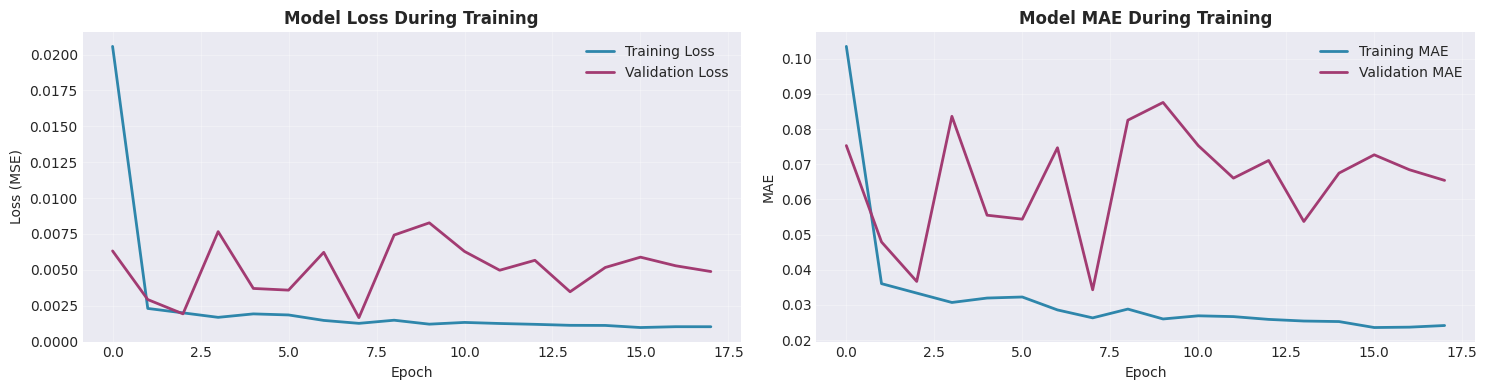

✓ Training history visualization saved!


In [16]:
# Training configuration
EPOCHS = 50
BATCH_SIZE = 32

print(f"Training configuration:")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Total training samples: {len(X_train)}")
print(f"  Total validation samples: {len(X_val)}")

print("\n📊 Starting model training...")
print("=" * 60)

# Train the model
history = lstm_model.train(
    X_train, y_train,
    X_val, y_val,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

print("\n✓ Training completed!")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Loss
axes[0].plot(history['loss'], label='Training Loss', linewidth=2, color='#2E86AB')
axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2, color='#A23B72')
axes[0].set_title('Model Loss During Training', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history['mae'], label='Training MAE', linewidth=2, color='#2E86AB')
axes[1].plot(history['val_mae'], label='Validation MAE', linewidth=2, color='#A23B72')
axes[1].set_title('Model MAE During Training', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/raulg/dev/laughing-couscous/models/03_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training history visualization saved!")

## 7. Evaluate Model Performance

Avaliaremos o modelo usando as métricas MAE, RMSE e MAPE.

Evaluating model on different datasets...


INFO:src.models.lstm_model:Evaluation Metrics - MAE: 5.0115, RMSE: 6.6449, MAPE: 0.0414
INFO:src.models.lstm_model:Evaluation Metrics - MAE: 8.9584, RMSE: 10.6477, MAPE: 0.0408



📈 Training Set Metrics:
  MAE: 5.011450
  RMSE: 6.644856
  MAPE: 0.041356

📈 Validation Set Metrics:
  MAE: 8.958356
  RMSE: 10.647735
  MAPE: 0.040783


INFO:src.models.lstm_model:Evaluation Metrics - MAE: 14.1334, RMSE: 16.8736, MAPE: 0.0568



📈 Test Set Metrics:
  MAE: 14.133415
  RMSE: 16.873574
  MAPE: 0.056763


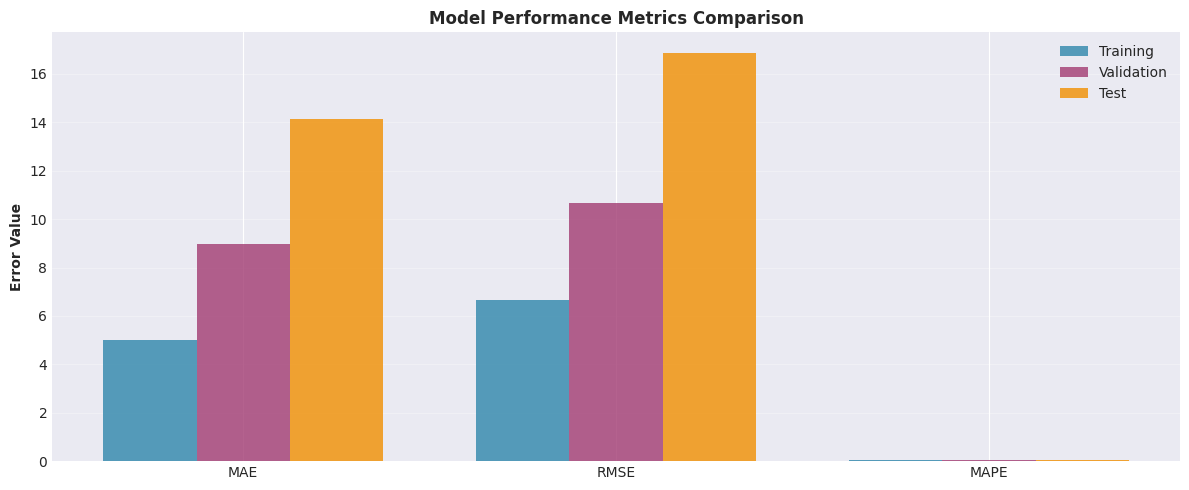


✓ Model evaluation completed!


In [17]:
print("Evaluating model on different datasets...")
print("=" * 60)

# Evaluate on training set
train_metrics = lstm_model.evaluate(X_train, y_train, scaler)
print(f"\n📈 Training Set Metrics:")
for metric, value in train_metrics.items():
    print(f"  {metric}: {value:.6f}")

# Evaluate on validation set
val_metrics = lstm_model.evaluate(X_val, y_val, scaler)
print(f"\n📈 Validation Set Metrics:")
for metric, value in val_metrics.items():
    print(f"  {metric}: {value:.6f}")

# Evaluate on test set
test_metrics = lstm_model.evaluate(X_test, y_test, scaler)
print(f"\n📈 Test Set Metrics:")
for metric, value in test_metrics.items():
    print(f"  {metric}: {value:.6f}")

# Create comparison visualization
fig, ax = plt.subplots(figsize=(12, 5))

metrics_names = list(test_metrics.keys())
train_values = [train_metrics[m] for m in metrics_names]
val_values = [val_metrics[m] for m in metrics_names]
test_values = [test_metrics[m] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.25

bars1 = ax.bar(x - width, train_values, width, label='Training', color='#2E86AB', alpha=0.8)
bars2 = ax.bar(x, val_values, width, label='Validation', color='#A23B72', alpha=0.8)
bars3 = ax.bar(x + width, test_values, width, label='Test', color='#F18F01', alpha=0.8)

ax.set_ylabel('Error Value', fontweight='bold')
ax.set_title('Model Performance Metrics Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/home/raulg/dev/laughing-couscous/models/04_evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Model evaluation completed!")

## 8. Make Predictions on Test Data

Fazeremos previsões nos dados de teste e compararemos com os valores reais.

Making predictions...
✓ Predictions completed!


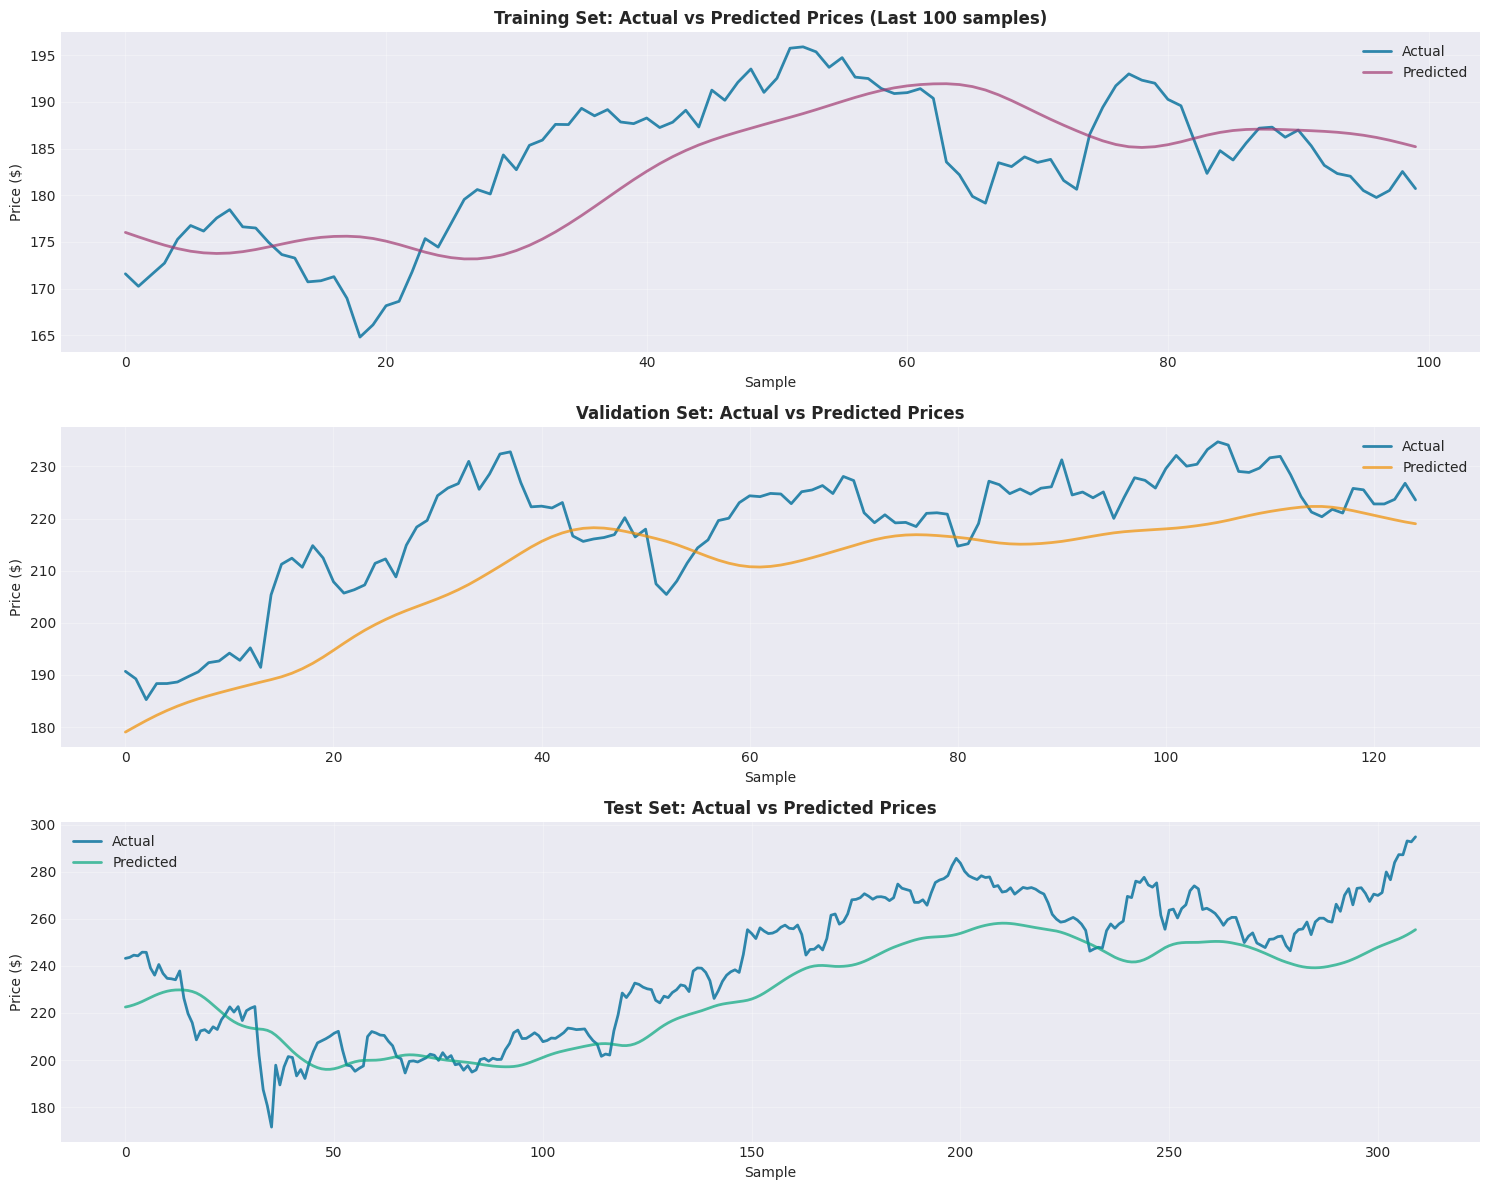

✓ Prediction visualization saved!

📊 Sample Test Predictions (Last 5 samples):
Actual       | Predicted    | Error ($)    | Error (%) 
--------------------------------------------------
287.25       | 251.46       | 35.78        | 12.46     %
287.18       | 252.28       | 34.89        | 12.15     %
293.05       | 253.20       | 39.85        | 13.60     %
292.68       | 254.23       | 38.45        | 13.14     %
294.80       | 255.36       | 39.44        | 13.38     %


In [18]:
# Make predictions on all datasets
print("Making predictions...")

train_pred = lstm_model.predict(X_train)
train_pred = scaler.inverse_transform(train_pred)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))

val_pred = lstm_model.predict(X_val)
val_pred = scaler.inverse_transform(val_pred)
y_val_actual = scaler.inverse_transform(y_val.reshape(-1, 1))

test_pred = lstm_model.predict(X_test)
test_pred = scaler.inverse_transform(test_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

print("✓ Predictions completed!")

# Create visualization comparing predictions vs actual
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Training predictions
axes[0].plot(y_train_actual[-100:], label='Actual', linewidth=2, color='#2E86AB')
axes[0].plot(train_pred[-100:], label='Predicted', linewidth=2, color='#A23B72', alpha=0.7)
axes[0].set_title('Training Set: Actual vs Predicted Prices (Last 100 samples)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Price ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation predictions
axes[1].plot(y_val_actual, label='Actual', linewidth=2, color='#2E86AB')
axes[1].plot(val_pred, label='Predicted', linewidth=2, color='#F18F01', alpha=0.7)
axes[1].set_title('Validation Set: Actual vs Predicted Prices', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Price ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Test predictions
axes[2].plot(y_test_actual, label='Actual', linewidth=2, color='#2E86AB')
axes[2].plot(test_pred, label='Predicted', linewidth=2, color='#06A77D', alpha=0.7)
axes[2].set_title('Test Set: Actual vs Predicted Prices', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Sample')
axes[2].set_ylabel('Price ($)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/raulg/dev/laughing-couscous/models/05_predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Prediction visualization saved!")

# Display sample predictions
print("\n📊 Sample Test Predictions (Last 5 samples):")
print(f"{'Actual':<12} | {'Predicted':<12} | {'Error ($)':<12} | {'Error (%)':<10}")
print("-" * 50)
for i in range(-5, 0):
    actual = y_test_actual[i][0]
    predicted = test_pred[i][0]
    error_abs = actual - predicted
    error_pct = (error_abs / actual) * 100
    print(f"{actual:<12.2f} | {predicted:<12.2f} | {error_abs:<12.2f} | {error_pct:<10.2f}%")

## 9. Save the Trained Model

Salvaremos o modelo treinado em formato .h5 para ser utilizado pela API.

In [19]:
import pickle
import json

# Save model
model_path = '/home/raulg/dev/laughing-couscous/models/lstm_model.h5'
lstm_model.save(model_path)
print(f"✓ Model saved to {model_path}")

# Save scaler
scaler_path = '/home/raulg/dev/laughing-couscous/models/scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✓ Scaler saved to {scaler_path}")

# Save model information
model_info = {
    'symbol': STOCK_SYMBOL,
    'lookback_period': LOOKBACK_PERIOD,
    'lstm_units': LSTM_UNITS,
    'dropout_rate': DROPOUT_RATE,
    'epochs_trained': len(history['loss']),
    'batch_size': BATCH_SIZE,
    'data_start_date': START_DATE,
    'data_end_date': END_DATE,
    'training_date': datetime.now().isoformat(),
    'test_metrics': {k: float(v) for k, v in test_metrics.items()},
    'validation_metrics': {k: float(v) for k, v in val_metrics.items()},
    'training_metrics': {k: float(v) for k, v in train_metrics.items()},
}

model_info_path = '/home/raulg/dev/laughing-couscous/models/model_info.json'
with open(model_info_path, 'w') as f:
    json.dump(model_info, f, indent=4)
print(f"✓ Model information saved to {model_info_path}")

print("\n📦 Model artifacts saved successfully!")
print(f"\nModel Configuration:")
for key, value in model_info.items():
    if isinstance(value, dict):
        print(f"  {key}:")
        for k, v in value.items():
            if isinstance(v, float):
                print(f"    {k}: {v:.6f}")
            else:
                print(f"    {k}: {v}")
    else:
        print(f"  {key}: {value}")

INFO:src.models.lstm_model:Model saved to /home/raulg/dev/laughing-couscous/models/lstm_model.h5


✓ Model saved to /home/raulg/dev/laughing-couscous/models/lstm_model.h5
✓ Scaler saved to /home/raulg/dev/laughing-couscous/models/scaler.pkl
✓ Model information saved to /home/raulg/dev/laughing-couscous/models/model_info.json

📦 Model artifacts saved successfully!

Model Configuration:
  symbol: AAPL
  lookback_period: 60
  lstm_units: 50
  dropout_rate: 0.2
  epochs_trained: 18
  batch_size: 32
  data_start_date: 2019-01-01
  data_end_date: 2026-05-13
  training_date: 2026-05-13T20:23:06.588801
  test_metrics:
    MAE: 14.133415
    RMSE: 16.873574
    MAPE: 0.056763
  validation_metrics:
    MAE: 8.958356
    RMSE: 10.647735
    MAPE: 0.040783
  training_metrics:
    MAE: 5.011450
    RMSE: 6.644856
    MAPE: 0.041356
